In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt

In [3]:
from sklearn.metrics import classification_report

In [4]:
df = pd.read_csv("gpt-image-1.5_generated_images.batch.merged_emotions.csv")

In [5]:
df.shape

(1642, 47)

In [6]:
df.columns

Index(['img_id', 'img_amusement_gpt', 'img_awe_gpt', 'img_contentment_gpt',
       'img_excitement_gpt', 'img_anger_gpt', 'img_disgust_gpt',
       'img_fear_gpt', 'img_sadness_gpt', 'img_id_raw', 'path', 'prompt',
       'img_amusement', 'img_awe', 'img_contentment', 'img_excitement',
       'img_anger', 'img_disgust', 'img_fear', 'img_sadness', 'text_amusement',
       'text_surprise', 'text_joy', 'text_excitement', 'text_anger',
       'text_disgust', 'text_fear', 'text_sadness', 'text_admiration',
       'text_annoyance', 'text_approval', 'text_caring', 'text_confusion',
       'text_curiosity', 'text_desire', 'text_disappointment',
       'text_disapproval', 'text_embarrassment', 'text_gratitude',
       'text_grief', 'text_love', 'text_nervousness', 'text_optimism',
       'text_pride', 'text_realization', 'text_relief', 'text_remorse'],
      dtype='object')

In [7]:
df.head(5)

,img_id,img_amusement_gpt,img_awe_gpt,img_contentment_gpt,img_excitement_gpt,img_anger_gpt,img_disgust_gpt,img_fear_gpt,img_sadness_gpt,img_id_raw,...,text_embarrassment,text_gratitude,text_grief,text_love,text_nervousness,text_optimism,text_pride,text_realization,text_relief,text_remorse
0,2062,0.023082,0.023449,0.025382,0.001484,0.560899,0.014845,0.212339,0.138520,img.00002062,...,0.000489,0.000291,0.000255,0.000284,0.000264,0.000324,0.000291,0.002279,0.000253,0.000253
1,2460,0.032744,0.073468,0.004304,0.007407,0.021842,0.004051,0.765134,0.091050,img.00002460,...,0.000360,0.000266,0.000223,0.000283,0.000240,0.000360,0.000319,0.009556,0.000234,0.000243
2,6317,0.140612,0.043718,0.102348,0.010898,0.075656,0.296297,0.268042,0.062430,img.00006317,...,0.000384,0.000279,0.000233,0.000754,0.000242,0.000416,0.000402,0.009311,0.000240,0.000239
3,291,0.198773,0.497123,0.074653,0.117578,0.031759,0.021544,0.033757,0.024814,img.00000291,...,0.000340,0.000339,0.000234,0.000245,0.000253,0.000425,0.000394,0.002418,0.000227,0.000259
4,4208,0.826381,0.020632,0.040620,0.015850,0.009147,0.020930,0.057562,0.008878,img.00004208,...,0.000627,0.000296,0.000281,0.000299,0.000283,0.000295,0.000434,0.001009,0.000252,0.000268


In [8]:
gpt_img_cs = [c for c in df.columns if "_gpt" in c]
gpt_img_cs

['img_amusement_gpt',
 'img_awe_gpt',
 'img_contentment_gpt',
 'img_excitement_gpt',
 'img_anger_gpt',
 'img_disgust_gpt',
 'img_fear_gpt',
 'img_sadness_gpt']

In [9]:
# For updated GPT-based emotions
for c in gpt_img_cs:
    tc = c.rpartition("_")[0]
    df[tc] = df[c]
    print(f"Replacing {tc} -> {c}")

Replacing img_amusement -> img_amusement_gpt
Replacing img_awe -> img_awe_gpt
Replacing img_contentment -> img_contentment_gpt
Replacing img_excitement -> img_excitement_gpt
Replacing img_anger -> img_anger_gpt
Replacing img_disgust -> img_disgust_gpt
Replacing img_fear -> img_fear_gpt
Replacing img_sadness -> img_sadness_gpt


In [10]:
dup_df = df.drop(columns=[
    "img_id",
    "img_id_raw",
] + gpt_img_cs)
img_cs = [c for c in dup_df.columns if c.startswith("img_")]
pmt_cs = [c for c in dup_df.columns if c.startswith("text_")]

In [11]:
pmt_cs

['text_amusement',
 'text_surprise',
 'text_joy',
 'text_excitement',
 'text_anger',
 'text_disgust',
 'text_fear',
 'text_sadness',
 'text_admiration',
 'text_annoyance',
 'text_approval',
 'text_caring',
 'text_confusion',
 'text_curiosity',
 'text_desire',
 'text_disappointment',
 'text_disapproval',
 'text_embarrassment',
 'text_gratitude',
 'text_grief',
 'text_love',
 'text_nervousness',
 'text_optimism',
 'text_pride',
 'text_realization',
 'text_relief',
 'text_remorse']

In [12]:
def generate_text_label(row):
    argmax = np.argmax(row[pmt_cs])
    return pmt_cs[argmax].partition("_")[-1]

def generate_image_label(row):
    argmax = np.argmax(row[img_cs])
    return img_cs[argmax].partition("_")[-1]

In [13]:
df["txt_label"] = df.apply(generate_text_label, axis=1)
df["img_label"] = df.apply(generate_image_label, axis=1)

In [14]:
df["txt_label"].value_counts()

txt_label
admiration        621
approval          460
annoyance         139
excitement        122
realization        82
fear               50
joy                47
surprise           19
sadness            17
amusement          16
optimism           14
disgust            12
love                9
anger               8
disappointment      7
curiosity           7
disapproval         4
caring              2
desire              2
remorse             1
embarrassment       1
gratitude           1
confusion           1
Name: count, dtype: int64

In [15]:
df["img_label"].value_counts()

img_label
fear           606
amusement      423
awe            170
sadness        143
anger          134
excitement      75
contentment     56
disgust         35
Name: count, dtype: int64

In [16]:
df[["img_label", "txt_label"]]

,img_label,txt_label
0,anger,admiration
1,fear,approval
2,disgust,admiration
3,awe,admiration
4,amusement,annoyance
...,...,...
1637,awe,admiration
1638,awe,approval
1639,fear,approval
1640,fear,admiration


In [17]:
tdf = df.copy()
tdf["mark"] = 1
pivot_txt = tdf[["mark","path", "txt_label"]].pivot(columns="txt_label", index="path", values="mark").fillna(0)
pivot_img = tdf[["mark","path", "img_label"]].pivot(columns="img_label", index="path", values="mark").fillna(0)

pivot_txt.columns = [c+"_txt" for c in pivot_txt.columns]
pivot_img.columns = [c+"_img" for c in pivot_img.columns]

In [18]:
joined_df = pivot_img.join(pivot_txt, lsuffix="_img", rsuffix="_txt")
joined_df

,amusement_img,anger_img,awe_img,contentment_img,disgust_img,excitement_img,fear_img,sadness_img,admiration_txt,amusement_txt,...,excitement_txt,fear_txt,gratitude_txt,joy_txt,love_txt,optimism_txt,realization_txt,remorse_txt,sadness_txt,surprise_txt
path,,,,,,,,,,,,,,,,,,,,,
diffusiondb_images_2m_random_10k/1003.png,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
diffusiondb_images_2m_random_10k/1009.png,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
diffusiondb_images_2m_random_10k/1011.png,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
diffusiondb_images_2m_random_10k/1014.png,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
diffusiondb_images_2m_random_10k/102.png,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
diffusiondb_images_2m_random_10k/981.png,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
diffusiondb_images_2m_random_10k/984.png,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
diffusiondb_images_2m_random_10k/989.png,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [19]:
corr_df = joined_df.corr()
e_cs = sorted(corr_df.columns)
rel_corr_df = corr_df.loc[[c for c in e_cs if "_img" in c]][[c for c in e_cs if "_txt" in c]]
rel_corr_df

,admiration_txt,amusement_txt,anger_txt,annoyance_txt,approval_txt,caring_txt,confusion_txt,curiosity_txt,desire_txt,disappointment_txt,...,excitement_txt,fear_txt,gratitude_txt,joy_txt,love_txt,optimism_txt,realization_txt,remorse_txt,sadness_txt,surprise_txt
amusement_img,-0.002807,0.026627,-0.041218,-0.019052,0.029455,-0.020571,-0.014542,0.025579,0.019355,0.004205,...,0.024274,-0.039557,0.041906,0.015803,-0.006008,-0.024334,-0.032761,-0.014542,-0.018978,0.014394
anger_img,0.015237,0.015723,0.043039,0.013238,-0.072025,-0.010410,-0.007359,0.014639,-0.010410,0.014639,...,0.042784,0.024853,-0.007359,0.002194,-0.022130,-0.003448,0.013360,0.082812,0.013465,-0.011452
awe_img,0.089480,-0.033711,0.004931,-0.045896,-0.056200,-0.011868,-0.008389,0.008446,-0.011868,-0.022236,...,0.010436,0.009579,-0.008389,0.013595,0.001847,0.033712,-0.022849,-0.008389,-0.034759,-0.018077
contentment_img,-0.001239,-0.018640,-0.013148,-0.033035,-0.012614,-0.006562,-0.004639,-0.012295,0.089641,-0.012295,...,0.010737,-0.013772,-0.004639,0.068360,-0.013950,-0.017425,-0.027676,-0.004639,0.047079,0.073796
disgust_img,-0.028145,-0.014639,-0.010326,0.046006,0.058167,-0.005154,-0.003643,-0.009656,-0.005154,-0.009656,...,-0.025732,-0.026154,-0.003643,-0.025333,-0.010956,-0.013686,-0.014477,-0.003643,-0.015095,-0.015968
excitement_img,-0.056331,0.126775,0.026585,0.017301,-0.013062,-0.007640,-0.005401,-0.014315,-0.007640,-0.014315,...,0.038123,-0.038771,-0.005401,0.049913,0.023267,0.043165,-0.009983,-0.005401,0.035258,-0.023671
fear_img,-0.000488,-0.037323,0.018986,0.012243,0.011892,0.009476,0.032277,-0.011302,-0.026709,-0.011302,...,-0.043434,0.070123,-0.018880,-0.048031,-0.005497,-0.002291,0.044829,-0.018880,-0.028354,-0.035547
sadness_img,-0.049360,-0.030638,-0.021612,0.030219,0.052614,0.051139,-0.007625,-0.020210,-0.010786,0.046092,...,-0.038089,-0.042167,-0.007625,-0.027113,0.035579,-0.005150,0.018431,-0.007625,0.053761,0.047366


In [20]:
rel_corr_df.columns


Index(['admiration_txt', 'amusement_txt', 'anger_txt', 'annoyance_txt',
       'approval_txt', 'caring_txt', 'confusion_txt', 'curiosity_txt',
       'desire_txt', 'disappointment_txt', 'disapproval_txt', 'disgust_txt',
       'embarrassment_txt', 'excitement_txt', 'fear_txt', 'gratitude_txt',
       'joy_txt', 'love_txt', 'optimism_txt', 'realization_txt', 'remorse_txt',
       'sadness_txt', 'surprise_txt'],
      dtype='object')

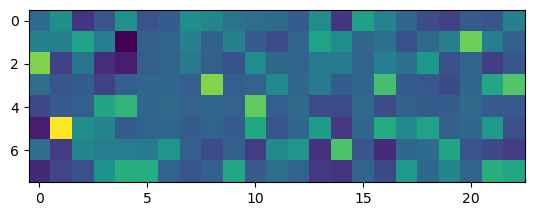

In [21]:
plt.imshow(rel_corr_df)

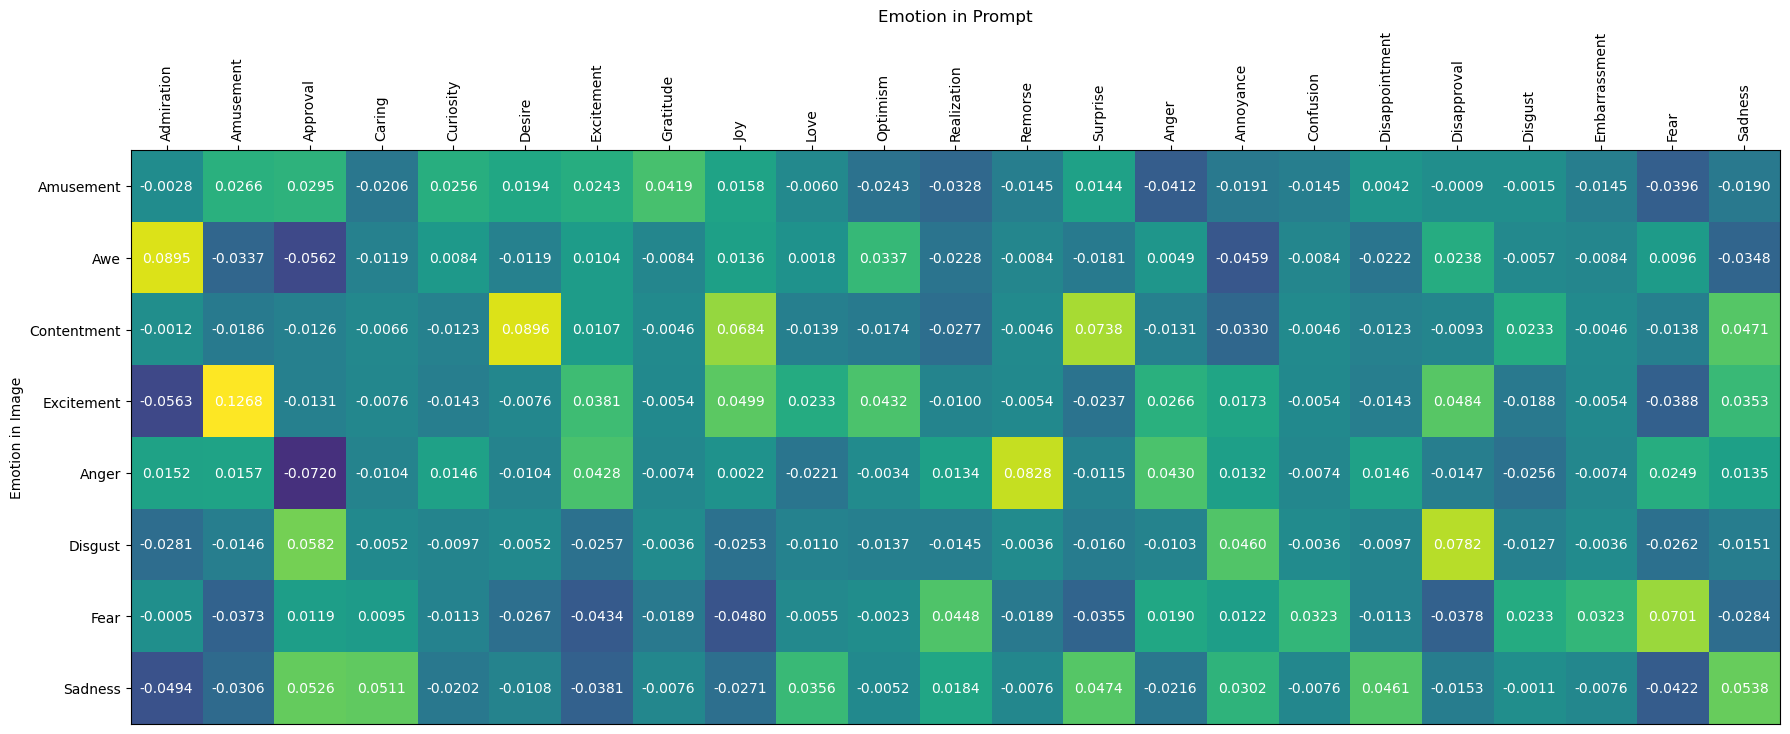

In [22]:
fig = plt.figure(figsize=(18,9))
ax = fig.add_subplot(1,1,1)
ax.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)

# row_i = rel_corr_df.index
# col_j = rel_corr_df.columns

row_i = [
    'amusement_img',
    'awe_img',
    'contentment_img',
    'excitement_img',
    'anger_img',
    'disgust_img',
    'fear_img',
    'sadness_img'
]
col_j = [
    'admiration_txt',
    'amusement_txt',
    'approval_txt',
    'caring_txt',
    'curiosity_txt',
    'desire_txt',
    'excitement_txt',
    'gratitude_txt',
    'joy_txt',
    'love_txt',
    'optimism_txt',
    # 'pride_txt',
    'realization_txt',
    'remorse_txt',
    'surprise_txt',
    
    'anger_txt',
    'annoyance_txt',
    'confusion_txt',
    'disappointment_txt',
    'disapproval_txt',
    'disgust_txt',
    'embarrassment_txt',
    'fear_txt',
    'sadness_txt',
]

row_labels = [c.partition("_")[0].title() for c in row_i]
col_labels = [c.partition("_")[0].title() for c in col_j]

target_df = rel_corr_df.loc[row_i][col_j]

ax.imshow(target_df.values, cmap='viridis', vmin=-0.1, vmax=0.1)
ax.set_yticks(ticks=range(0,len(row_labels)), labels=row_labels, rotation=0)
ax.set_xticks(ticks=range(0,len(col_labels)), labels=col_labels, rotation=90)

# Loop over data dimensions and create text annotations.
for i in range(len(row_labels)):
    for j in range(len(col_labels)):
        text = ax.text(j, i, "%0.04f" % target_df.values[i, j], ha="center", va="center", color="w")

ax.set_ylabel("Emotion in Image")
ax.set_title("Emotion in Prompt")

plt.tight_layout()
plt.savefig("full_img_to_txt.gpt.pdf", format="pdf")


In [23]:
# aligned_emotions = {
#     "amusement": "amusement",
#     "anger": "anger",
#     "disgust": "disgust",
#     "excitement": "excitement",
#     "fear": "fear",
#     "sadness": "sadness",
#     "joy": "contentment",
#     "love": "amusement",
#     "contentment": "contentment",
#     "awe": "awe",
#     "admiration": "awe",
# }

aligned_emotions = {
    # EmoSet
    "amusement": "joy",
    "awe": "surprise",
    "excitement": "joy",
    "contentment": "joy",
    "fear": "fear",
    "anger": "anger",
    "disgust": "disgust",
    "sadness": "sadness",

    # GoEmotions
    "annoyance": "anger",
    "disapproval": "anger",
    "nervousness": "fear",
    "disappointment": "sadness",
    "embarrassment": "sadness",
    "grief": "sadness",
    "remorse": "sadness",
    "admiration": "joy",
    "amusement": "joy",
    "approval": "joy",
    "caring": "joy",
    "desire": "joy",
    "excitement": "joy",
    "gratitude": "joy",
    "love": "joy",
    "joy": "joy",
    "optimism": "joy",
    "pride": "joy",
    "remorse": "joy",
    "curiosity": "surprise",
    "realization": "surprise",
    "surprise": "surprise",
    "confusion": "surprise",
}

e_cs = list(set(aligned_emotions.values()))
e_cs

['joy', 'disgust', 'fear', 'anger', 'sadness', 'surprise']

In [24]:
df["txt_label_aligned"] = df["txt_label"].apply(lambda s: aligned_emotions.get(s,"OTHER"))
df["img_label_aligned"] = df["img_label"].apply(lambda s: aligned_emotions.get(s,"OTHER"))


In [25]:
df["txt_label_aligned"].value_counts()

txt_label_aligned
joy         1295
anger        151
surprise     109
fear          50
sadness       25
disgust       12
Name: count, dtype: int64

In [26]:
df["img_label_aligned"].value_counts()

img_label_aligned
fear        606
joy         554
surprise    170
sadness     143
anger       134
disgust      35
Name: count, dtype: int64

In [27]:
tdf = df.copy()
tdf["mark"] = 1
pivot_txt = tdf[["mark","path", "txt_label_aligned"]].pivot(columns="txt_label_aligned", index="path", values="mark").fillna(0)
pivot_img = tdf[["mark","path", "img_label_aligned"]].pivot(columns="img_label_aligned", index="path", values="mark").fillna(0)

In [28]:
joined_df = pivot_img.join(pivot_txt, lsuffix="_img", rsuffix="_txt")
joined_df

,anger_img,disgust_img,fear_img,joy_img,sadness_img,surprise_img,anger_txt,disgust_txt,fear_txt,joy_txt,sadness_txt,surprise_txt
path,,,,,,,,,,,,
diffusiondb_images_2m_random_10k/1003.png,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
diffusiondb_images_2m_random_10k/1009.png,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
diffusiondb_images_2m_random_10k/1011.png,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
diffusiondb_images_2m_random_10k/1014.png,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
diffusiondb_images_2m_random_10k/102.png,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
diffusiondb_images_2m_random_10k/981.png,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
diffusiondb_images_2m_random_10k/984.png,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
diffusiondb_images_2m_random_10k/989.png,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [29]:
corr_df = joined_df.corr()
rel_corr_df = corr_df.loc[[c+"_img" for c in e_cs]][[c+"_txt" for c in e_cs]]
rel_corr_df

,joy_txt,disgust_txt,fear_txt,anger_txt,sadness_txt,surprise_txt
joy_img,0.057029,-0.000737,-0.058993,-0.026505,0.005945,-0.024710
disgust_img,-0.006234,-0.012663,-0.026154,0.055176,-0.018350,-0.022415
fear_img,-0.049263,0.023282,0.070123,0.009921,-0.022949,0.024193
anger_img,-0.030962,-0.025577,0.024853,0.020610,0.017437,0.009872
sadness_img,-0.035871,-0.001143,-0.042167,0.021299,0.067431,0.030429
surprise_img,0.053499,-0.005689,0.009579,-0.038971,-0.042256,-0.026378


In [30]:
rel_corr_df.index

Index(['joy_img', 'disgust_img', 'fear_img', 'anger_img', 'sadness_img',
       'surprise_img'],
      dtype='object')

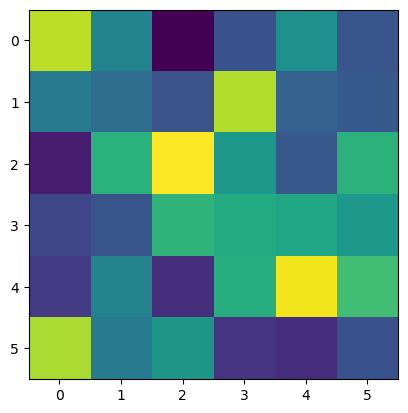

In [31]:
plt.imshow(rel_corr_df)

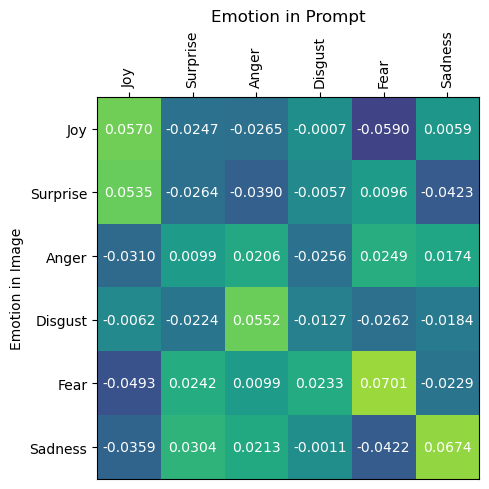

In [32]:
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(1,1,1)
ax.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)

# row_i = rel_corr_df.index
# col_j = rel_corr_df.columns

row_i = [
    'joy_img',
    'surprise_img',
    'anger_img',
    'disgust_img', 
    'fear_img', 
    'sadness_img',   
]
col_j = [
    'joy_txt',
    'surprise_txt',
    'anger_txt',
    'disgust_txt', 
    'fear_txt', 
    'sadness_txt',   
]

row_labels = [c.partition("_")[0].title() for c in row_i]
col_labels = [c.partition("_")[0].title() for c in col_j]

target_df = rel_corr_df.loc[row_i][col_j]

ax.imshow(target_df.values, cmap='viridis', vmin=-0.1, vmax=0.1)
ax.set_yticks(ticks=range(0,len(row_labels)), labels=row_labels, rotation=0)
ax.set_xticks(ticks=range(0,len(col_labels)), labels=col_labels, rotation=90)

# Loop over data dimensions and create text annotations.
for i in range(len(row_labels)):
    for j in range(len(col_labels)):
        text = ax.text(j, i, "%0.04f" % target_df.values[i, j], ha="center", va="center", color="w")

ax.set_ylabel("Emotion in Image")
ax.set_title("Emotion in Prompt")

plt.tight_layout()
plt.savefig("ekman_img_to_txt.gpt.pdf", format="pdf")



In [33]:
rel_corr_df.max().max()

0.07012332992977283

In [34]:
np.mean([rel_corr_df.loc[row_i[i]][col_j[i]] for i in range(6)])

np.float64(0.02935866632504744)

In [35]:
print(classification_report(df["txt_label_aligned"], df["img_label_aligned"]))

              precision    recall  f1-score   support

       anger       0.11      0.10      0.11       151
     disgust       0.00      0.00      0.00        12
        fear       0.05      0.56      0.09        50
         joy       0.82      0.35      0.49      1295
     sadness       0.04      0.24      0.07        25
    surprise       0.05      0.07      0.06       109

    accuracy                           0.31      1642
   macro avg       0.18      0.22      0.14      1642
weighted avg       0.66      0.31      0.41      1642



In [36]:
pos_neg_groups = {
    "anger": "NEGATIVE",
    "disgust": "NEGATIVE",
    "fear": "NEGATIVE",
    "sadness": "NEGATIVE",
    "surprise": "AMBIGUOUS",
    "joy": "POSITIVE",
}
inv_pos_neg_groups = {}
for k,v in pos_neg_groups.items():
    inv_pos_neg_groups[v] = inv_pos_neg_groups.get(v,[]) + [k]

In [37]:
df["txt_label_group"] = df["txt_label_aligned"].apply(lambda s: pos_neg_groups.get(s,"OTHER"))
df["img_label_group"] = df["img_label_aligned"].apply(lambda s: pos_neg_groups.get(s,"OTHER"))


In [38]:
df["txt_label_group"].value_counts()

txt_label_group
POSITIVE     1295
NEGATIVE      238
AMBIGUOUS     109
Name: count, dtype: int64

In [39]:
df["img_label_group"].value_counts()

img_label_group
NEGATIVE     918
POSITIVE     554
AMBIGUOUS    170
Name: count, dtype: int64

In [40]:
tdf = df.copy()
tdf["mark"] = 1

In [41]:
pivot_txt = tdf[["mark","path", "txt_label_group"]].pivot(columns="txt_label_group", index="path", values="mark").fillna(0)
pivot_img = tdf[["mark","path", "img_label_group"]].pivot(columns="img_label_group", index="path", values="mark").fillna(0)

In [42]:
highest_agg = list(set(pos_neg_groups.values()))

joined_df = pivot_img.join(pivot_txt, lsuffix="_img", rsuffix="_txt")
corr_df = joined_df.corr()
rel_corr_df = corr_df.loc[[c+"_img" for c in highest_agg]][[c+"_txt" for c in highest_agg]]
rel_corr_df

,NEGATIVE_txt,AMBIGUOUS_txt,POSITIVE_txt
NEGATIVE_img,0.072961,0.039717,-0.087136
AMBIGUOUS_img,-0.043387,-0.026378,0.053499
POSITIVE_img,-0.048660,-0.024710,0.057029


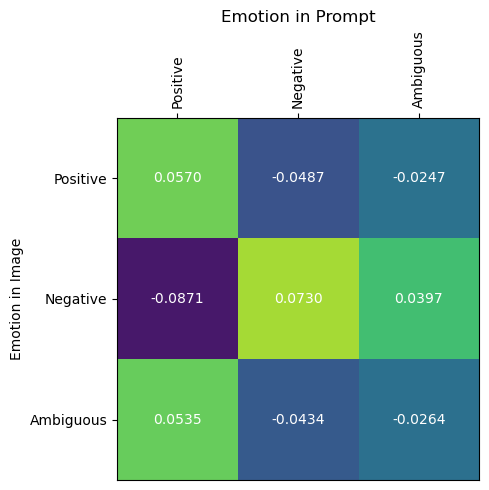

In [43]:
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(1,1,1)
ax.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)

# row_i = rel_corr_df.index
# col_j = rel_corr_df.columns

row_i = [
    'POSITIVE_img',
    'NEGATIVE_img',
    'AMBIGUOUS_img',
]
col_j = [
    'POSITIVE_txt',
    'NEGATIVE_txt',
    'AMBIGUOUS_txt', 
]

row_labels = [c.partition("_")[0].title() for c in row_i]
col_labels = [c.partition("_")[0].title() for c in col_j]

target_df = rel_corr_df.loc[row_i][col_j]

ax.imshow(target_df.values, cmap='viridis', vmin=-0.1, vmax=0.1)
ax.set_yticks(ticks=range(0,len(row_labels)), labels=row_labels, rotation=0)
ax.set_xticks(ticks=range(0,len(col_labels)), labels=col_labels, rotation=90)

# Loop over data dimensions and create text annotations.
for i in range(len(row_labels)):
    for j in range(len(col_labels)):
        text = ax.text(j, i, "%0.04f" % target_df.values[i, j], ha="center", va="center", color="w")

ax.set_ylabel("Emotion in Image")
ax.set_title("Emotion in Prompt")

plt.tight_layout()
plt.savefig("ekman_img_to_txt.pdf", format="pdf")

In [44]:
# True positive rate
for pl in set(aligned_emotions.values()):
    group = df[df["txt_label_aligned"] == pl]
    hit_rate = sum(group["img_label_aligned"] == pl) / group.shape[0]
    print(pl, hit_rate)

joy 0.35135135135135137
disgust 0.0
fear 0.56
anger 0.09933774834437085
sadness 0.24
surprise 0.07339449541284404


In [45]:
# False positive rate
for pl in set(aligned_emotions.values()):
    group = df[df["img_label_aligned"] == pl]
    fps = sum(group["txt_label_aligned"] != pl)

    fpr_rate = fps / df[df["txt_label_aligned"] != pl].shape[0]
    print(pl, fpr_rate)

joy 0.28530259365994237
disgust 0.02147239263803681
fear 0.3630653266331658
anger 0.07981220657276995
sadness 0.0847247990105133
surprise 0.10567514677103718


In [46]:
# False negative rate
for pl in set(aligned_emotions.values()):
    group = df[df["txt_label_aligned"] == pl]
    miss_rate = sum(group["img_label_aligned"] != pl) / group.shape[0]
    print(pl, miss_rate)

joy 0.6486486486486487
disgust 1.0
fear 0.44
anger 0.9006622516556292
sadness 0.76
surprise 0.926605504587156


In [47]:
for group in {"NEGATIVE", "POSITIVE", "AMBIGUOUS"}:
    print(group)
    local_df = df[df["txt_label_group"] == group]
    ma_tprs = []
    
    for pl in inv_pos_neg_groups[group]:
        group = df[df["txt_label_aligned"] == pl]
        hit_rate = sum(group["img_label_aligned"] == pl) / group.shape[0]
        print("\t", pl, hit_rate)
        ma_tprs.append(hit_rate)

    print(np.mean(ma_tprs), np.std(ma_tprs))

NEGATIVE
	 anger 0.09933774834437085
	 disgust 0.0
	 fear 0.56
	 sadness 0.24
0.22483443708609271 0.21146269874782223
POSITIVE
	 joy 0.35135135135135137
0.35135135135135137 0.0
AMBIGUOUS
	 surprise 0.07339449541284404
0.07339449541284404 0.0


In [48]:
for group in {"NEGATIVE", "POSITIVE", "AMBIGUOUS"}:
    print(group)
    local_df = df[df["txt_label_group"] == group]
    ma_fprs = []
    
    for pl in inv_pos_neg_groups[group]:
        group = df[df["txt_label_aligned"] == pl]
        miss_rate = sum(group["img_label_aligned"] != pl) / group.shape[0]
        print("\t", pl, miss_rate)
        ma_fprs.append(miss_rate)

    print(np.mean(ma_fprs), np.std(ma_fprs))

NEGATIVE
	 anger 0.9006622516556292
	 disgust 1.0
	 fear 0.44
	 sadness 0.76
0.7751655629139074 0.21146269874782223
POSITIVE
	 joy 0.6486486486486487
0.6486486486486487 0.0
AMBIGUOUS
	 surprise 0.926605504587156
0.926605504587156 0.0


In [49]:
# Bootstrap the sample
all_mrs = []
all_hrs = []
all_fprs = []
for i in range(1000):
    bt_df = df.sample(frac=1, replace=True)

    local_hr = {}
    local_mr = {}
    local_fpr = {}
    for pl in set(aligned_emotions.values()):
        group = bt_df[bt_df["txt_label_aligned"] == pl]
        
        hit_rate = sum(group["img_label_aligned"] == pl) / group.shape[0]
        local_hr[pl] = hit_rate
        
        miss_rate = sum(group["img_label_aligned"] != pl) / group.shape[0]
        local_mr[pl] = miss_rate

        pos_group = bt_df[bt_df["img_label_aligned"] == pl]
        fps = sum(pos_group["txt_label_aligned"] != pl)
        fp_rate = fps / bt_df[bt_df["txt_label_aligned"] != pl].shape[0]
        local_fpr[pl] = fp_rate
            
    all_hrs.append(local_hr)
    all_mrs.append(local_mr)
    all_fprs.append(local_fpr)

In [50]:
all_fprs

[{'joy': 0.29376854599406527,
  'disgust': 0.026348039215686275,
  'fear': 0.3707653701380176,
  'anger': 0.08171466845277964,
  'sadness': 0.0847247990105133,
  'surprise': 0.10084580351333768},
 {'joy': 0.31179775280898875,
  'disgust': 0.015980331899200985,
  'fear': 0.35570890840652447,
  'anger': 0.08675184936112978,
  'sadness': 0.080545229244114,
  'surprise': 0.10704960835509138},
 {'joy': 0.26409495548961426,
  'disgust': 0.02386780905752754,
  'fear': 0.36983729662077597,
  'anger': 0.06032171581769437,
  'sadness': 0.09113453192808431,
  'surprise': 0.107421875},
 {'joy': 0.3271276595744681,
  'disgust': 0.019656019656019656,
  'fear': 0.34452184927169094,
  'anger': 0.08450704225352113,
  'sadness': 0.07716049382716049,
  'surprise': 0.10620052770448549},
 {'joy': 0.29178470254957506,
  'disgust': 0.02022058823529412,
  'fear': 0.3755513547574039,
  'anger': 0.07152406417112299,
  'sadness': 0.08286951144094001,
  'surprise': 0.10819672131147541},
 {'joy': 0.289855072463768

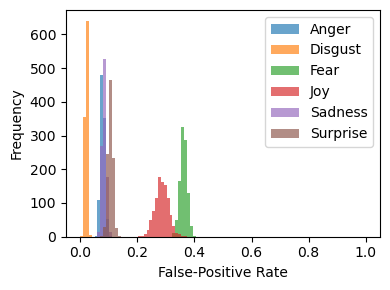

In [51]:
fig = plt.figure(figsize=(4,3))
ax = fig.add_subplot(1,1,1)

fpr_df = pd.DataFrame(all_fprs)
fpr_df.columns = [c.title() for c in fpr_df.columns]
sortc = sorted(fpr_df.columns)
fpr_df[sortc].plot.hist(bins=np.linspace(0,1,100), alpha=0.67, ax=ax)
ax.set_xlabel("False-Positive Rate")

plt.tight_layout()
plt.savefig("fp_rate.gpt.pdf", format="pdf")

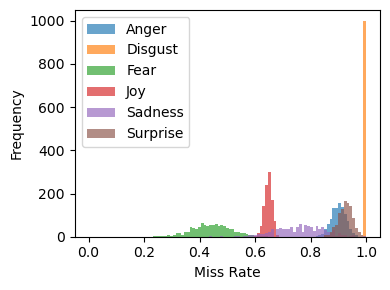

In [52]:
fig = plt.figure(figsize=(4,3))
ax = fig.add_subplot(1,1,1)

mr_df = pd.DataFrame(all_mrs)
mr_df.columns = [c.title() for c in mr_df.columns]
sortc = sorted(mr_df.columns)
mr_df[sortc].plot.hist(bins=np.linspace(0,1,100), alpha=0.67, ax=ax)
ax.set_xlabel("Miss Rate")

plt.tight_layout()
plt.savefig("miss_rate.gpt.pdf", format="pdf")

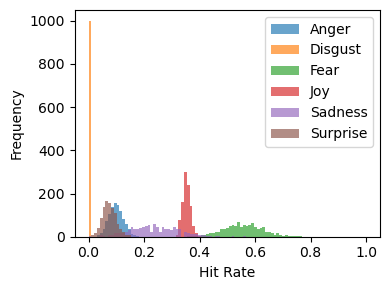

In [53]:
fig = plt.figure(figsize=(4,3))
ax = fig.add_subplot(1,1,1)

hr_df = pd.DataFrame(all_hrs)
hr_df.columns = [c.title() for c in hr_df.columns]
sortc = sorted(hr_df.columns)
hr_df[sortc].plot.hist(bins=np.linspace(0,1,100), alpha=0.67, ax=ax)
ax.set_xlabel("Hit Rate")

plt.tight_layout()
plt.savefig("hit_rate.gpt.pdf", format="pdf")

Joy: 0.3273, 0.3525, 0.3804
Disgust: 0.0000, 0.0000, 0.0000
Fear: 0.4167, 0.5569, 0.7027
Anger: 0.0510, 0.0998, 0.1533
Sadness: 0.0870, 0.2404, 0.4194
Surprise: 0.0288, 0.0749, 0.1273


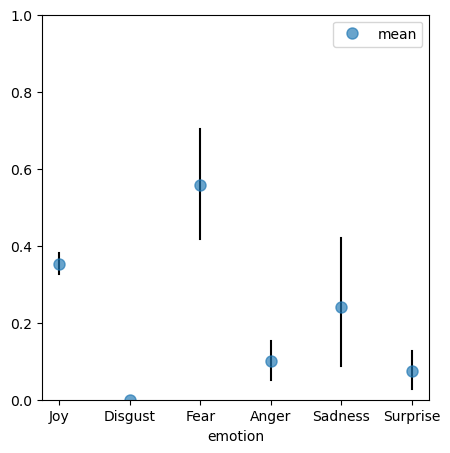

In [54]:
rows = []
for c_ in e_cs:
    c = c_.title()
    low_i = int(hr_df.shape[0] * 0.025)
    hi_i = int(hr_df.shape[0] * 0.975)
    sorted_df = hr_df.sort_values(by=c)
    l_mean = sorted_df[c].mean()
    ci_l = sorted_df[c].values[low_i]
    ci_h = sorted_df[c].values[hi_i]
    print("%s: %0.4f, %0.4f, %0.4f" % (c, ci_l, l_mean, ci_h))

    rows.append((c, ci_l, l_mean, ci_h))
metrcis_df = pd.DataFrame(rows, columns=["emotion", "ci_l", "mean", "ci_h"])

fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(1,1,1)
ax.set_ylim((0,1))
for idx,row in metrcis_df.iterrows():
    ax.plot([row["emotion"], row["emotion"]], [row["ci_l"], row["ci_h"]], color="black")
metrcis_df.plot(x="emotion", y="mean", linestyle='', marker="o", markersize=8, ax=ax, alpha=0.67)
plt.show()

Joy: 0.6196, 0.6475, 0.6728
Disgust: 1.0000, 1.0000, 1.0000
Fear: 0.2973, 0.4431, 0.5833
Anger: 0.8472, 0.9002, 0.9494
Sadness: 0.5833, 0.7596, 0.9167
Surprise: 0.8736, 0.9251, 0.9712


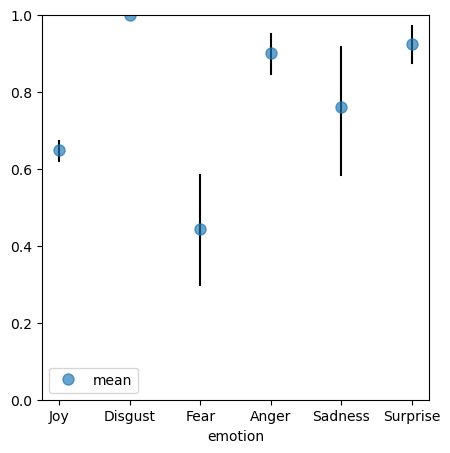

In [55]:
rows = []
for c_ in e_cs:
    c = c_.title()
    low_i = int(hr_df.shape[0] * 0.025)
    hi_i = int(hr_df.shape[0] * 0.975)
    sorted_df = mr_df.sort_values(by=c)
    l_mean = sorted_df[c].mean()
    ci_l = sorted_df[c].values[low_i]
    ci_h = sorted_df[c].values[hi_i]
    print("%s: %0.4f, %0.4f, %0.4f" % (c, ci_l, l_mean, ci_h))

    rows.append((c, ci_l, l_mean, ci_h))
metrcis_df = pd.DataFrame(rows, columns=["emotion", "ci_l", "mean", "ci_h"])

fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(1,1,1)
ax.set_ylim((0,1))
for idx,row in metrcis_df.iterrows():
    ax.plot([row["emotion"], row["emotion"]], [row["ci_l"], row["ci_h"]], color="black")
metrcis_df.plot(x="emotion", y="mean", linestyle='', marker="o", markersize=8, ax=ax, alpha=0.67)
plt.show()

Joy: 0.2387, 0.2861, 0.3323
Disgust: 0.0147, 0.0214, 0.0288
Fear: 0.3384, 0.3621, 0.3861
Anger: 0.0651, 0.0793, 0.0938
Sadness: 0.0716, 0.0848, 0.0993
Surprise: 0.0907, 0.1058, 0.1214


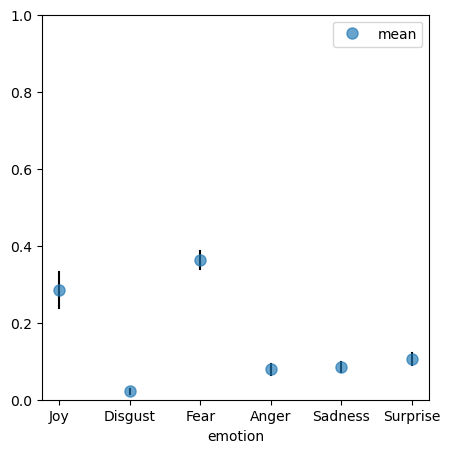

In [56]:
rows = []
for c_ in e_cs:
    c = c_.title()
    low_i = int(fpr_df.shape[0] * 0.025)
    hi_i = int(fpr_df.shape[0] * 0.975)
    sorted_df = fpr_df.sort_values(by=c)
    l_mean = sorted_df[c].mean()
    ci_l = sorted_df[c].values[low_i]
    ci_h = sorted_df[c].values[hi_i]
    print("%s: %0.4f, %0.4f, %0.4f" % (c, ci_l, l_mean, ci_h))

    rows.append((c, ci_l, l_mean, ci_h))
metrcis_df = pd.DataFrame(rows, columns=["emotion", "ci_l", "mean", "ci_h"])

fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(1,1,1)
ax.set_ylim((0,1))
for idx,row in metrcis_df.iterrows():
    ax.plot([row["emotion"], row["emotion"]], [row["ci_l"], row["ci_h"]], color="black")
metrcis_df.plot(x="emotion", y="mean", linestyle='', marker="o", markersize=8, ax=ax, alpha=0.67)
plt.show()

In [57]:
# Bootstrap the sample
all_g_mrs = []
for i in range(1000):
    bt_df = df.sample(frac=1, replace=True)

    local_mr = {}
    for group_name in {"NEGATIVE", "POSITIVE", "AMBIGUOUS"}:
        local_df = bt_df[bt_df["txt_label_group"] == group_name]
        ma_fprs = []
        for pl in inv_pos_neg_groups[group_name]:
            group = bt_df[bt_df["txt_label_aligned"] == pl]
            miss_rate = sum(group["img_label_aligned"] != pl) / group.shape[0]
            ma_fprs.append(miss_rate)
    
        local_mr[group_name] = np.mean(ma_fprs)

    all_g_mrs.append(local_mr)

Text(0.5, 0, 'Miss Rate')

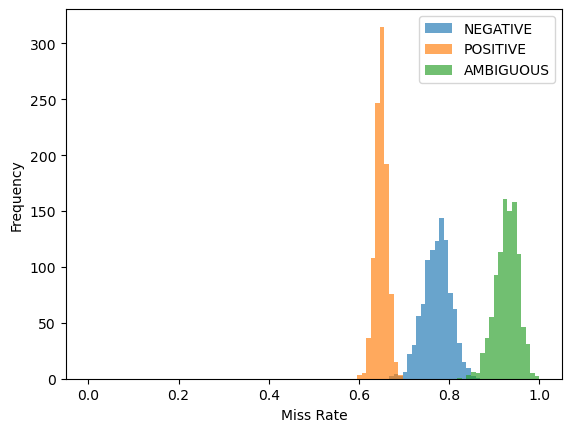

In [58]:
hr_df = pd.DataFrame(all_g_mrs)
hr_df.plot.hist(bins=np.linspace(0,1,100), alpha=0.67)
plt.xlabel("Miss Rate")